In [ ]:
"""
In this notebook, the preparation of the raw data from ChEMBL is done
"""

In [1]:
import re
from typing import Dict

import polars as pl
from matplotlib.patches import Patch
import seaborn as sns

from novami.io import read_pl, write_pl
from novami.visualize.utils import *

In [27]:
def extract(string: str, pattern: re.Pattern):
    """
    Find all instances of provided pattern in the string.
    """
    matches = re.findall(pattern, string) # List[str]
    if not matches:
        return None
    else:
        return ";".join(sorted(set(matches)))

def extract_dict(string: str, patterns: Dict[str, re.Pattern], key_name: str, match_name: str):
    names = []
    matches = []

    for name, pattern in patterns.items():
        out = re.findall(pattern, string)
        if out:
            names.append(name)
            matches.extend(out)

    if names:
        names = list(set(names))
        matches = list(set(matches))
        return {key_name: ";".join(names), match_name: ";".join(matches)}
    return {key_name: None, match_name: None}

# Assay-level preparation

## Initial operations

In [24]:
df = read_pl("../data/ChEMBL/raw/ion_channel_assays.tsv")

In [25]:
# Join target information from UniProt
uniprot = read_pl("../data/ChEMBL/maps/uniprot.tsv")
df = df.drop(["tax_id", "target_type", "organism"])
df = df.join(uniprot, on="target_chembl_id", how="left")

In [26]:
# Assay type in B (BINDING), F (FUNCTIONAL), A (ADME) or T (TOXICITY)
df = df.with_columns(
    ~pl.col("assay_type").is_in(["B", "F", "A", "T"]).alias("Assay Flag")
)

In [27]:
# Encode BAO Class
bao_class = {
    "BAO_0000019": "Assay format",
    "BAO_0000218": "Organism-based format",
    "BAO_0000219": "Cell-based format",
    "BAO_0000220": "Subcellular format",
    "BAO_0000221": "Tissue-based format",
    "BAO_0000223": "Protein complex format",
    "BAO_0000224": "Protein format",
    "BAO_0000249": "Cell membrane format",
    "BAO_0000357": "Single protein format"
}

df = df.with_columns([
    pl.col('bao_format').map_elements(lambda bao: bao_class.get(bao, "")).alias("BAO Class"),
]).drop("bao_format")

In [28]:
# Organism/subcellular/tissue-level measurements preferred
df = df.with_columns(
    pl.col("BAO Class").is_in([
        "Organism-based format",
        "Subcellular format",
        "Tissue-based format"
    ]).alias("BAO Flag")
)

In [29]:
# Target type should be a single protein or a complex
target_primary = {"SINGLE PROTEIN", "PROTEIN COMPLEX"}
target_pretrain = {"PROTEIN COMPLEX GROUP"}
target_drop = {"SELECTIVITY GROUP", "PROTEIN-PROTEIN INTERACTION", "PROTEIN FAMILY"}

df = df.with_columns(
    pl.when(pl.col("target_type").is_in(target_primary))
        .then(pl.lit("Primary"))
        .when(pl.col("target_type").is_in(target_pretrain))
        .then(pl.lit("Pretrain"))
        .otherwise(pl.lit("Drop"))
        .alias("Target Flag")
)

In [340]:
# Human vs Mammalian differentiated
df = df.with_columns(
    pl.when(pl.col('organism') == "Homo sapiens")
    .then(pl.lit("Human"))
    .otherwise(pl.lit("Mammalian"))
    .alias("Organism Flag")
)

In [341]:
# Mutant sequences flagged
mutant_regex = re.compile(
    r"\b(mutant|mutation|mut\b|truncat|chimera|chimer|"
    r"deletion|del\b|knock.?in|knock.?out|"
    r"gain.of.function|loss.of.function|"
    r"[A-Z]\d+[A-Z]\b|"        # point mutation notation e.g. G551D
    r"dominant.negative|"
    r"constitutive(?:ly).active)\b", re.I
)

df = df.with_columns(
    pl.col("assay_description").map_elements(
        lambda desc: extract(desc, mutant_regex),
        return_dtype=pl.String
    ).alias("RE Mutant")
).with_columns(
    pl.col("RE Mutant").is_not_null().alias("Mutant Flag")
)

In [342]:
# Confidence score should be at least 6 for Pretrain and at least 8 for Primary
df = df.with_columns(
    pl.when(pl.col("confidence_score") >= 8)
      .then(pl.lit("Primary"))
      .when(pl.col("confidence_score").is_in([6, 7]))
      .then(pl.lit("Pretrain"))
      .otherwise(pl.lit("Drop"))
      .alias("Confidence Flag")
)

In [343]:
# Map literature source
src_map = {
    1: "LITERATURE",
    7: "PUBCHEM_BIOASSAY",
    15: "DRUGMATRIX",
    17: "MMV_MBOX",
    23: "OSM",
    28: "FDA_APPROVDAL",
    37: "BINDINGDB",
    38: "PATENT",
    52: "SARS_COV_2",
    54: "DONATED_PROBES",
    65: "LIT_EUBOPEN_CGL",
    71: "ASAP",
    72: "LIT_CHEM_PROBES"
}

df = df.with_columns(
    pl.col("src_id").map_elements(
        lambda src: src_map.get(src, ""),
        return_dtype=pl.String
    ).alias("Source")
).drop("src_id")

In [344]:
# Check for unwanted/unexpected/erroneous genes
from itertools import chain
genes = sorted(df['gene_name'].str.to_uppercase().unique().to_list())
genes = sorted(set(chain.from_iterable([gene.split(";") for gene in genes])))
print(genes)

['CACNA1C', 'CACNA2D1', 'CACNB1', 'CACNB2', 'CACNB3', 'KCND3', 'KCNE1', 'KCNH2', 'KCNIP2', 'KCNJ2', 'KCNQ1', 'MINK1', 'SCN1B', 'SCN2B', 'SCN5A']


In [345]:
primary_genes = ["KCNH2", "SCN5A", "CACNA1C", "KCND3", "KCNJ2", "KCNQ1"]
unexpected_genes = ["MINK1"]

In [346]:
df = df.with_columns([
    pl.when(pl.col("gene_name").str.contains_any(primary_genes))
        .then(pl.lit("Primary"))
        .otherwise(pl.lit("Pretrain"))
        .alias("Gene Tier"),
    pl.col("gene_name").str.contains_any(unexpected_genes).alias("Gene Flag"),
])

In [347]:
# Add document information
docs_df = read_pl("../data/ChEMBL/maps/documents.tsv")
assay_2_doc = read_pl("../data/ChEMBL/maps/assay_2_doc.tsv")
df = df.join(assay_2_doc, on="assay_chembl_id", how="left").join(docs_df, on="document_chembl_id", how="left")

In [348]:
# Add assay measurement counts
counts_df = read_pl("../data/ChEMBL/maps/compound_counts.tsv")
df = df.join(counts_df, on="assay_chembl_id", how="left")

In [349]:
# Add cell information
cell_df = read_pl("../data/ChEMBL/maps/assay_2_cells.tsv").select(["assay_chembl_id", "cell_name", "cell_source_organism"])
df = df.join(cell_df, on="assay_chembl_id", how="left")

In [350]:
print(sorted(df["cell_name"].drop_nulls().unique().to_list()))

['A7R5', 'CHO', 'CHO-K1', 'COS-7', 'Cardiac Muscle Cell', 'H9c2', 'HEK293', 'HEK293-A', 'HEL', 'HT-29', 'L929', 'MCF7', 'NULL', 'Oocyte', 'Sf9', 'Ventricular myocyte']


In [351]:
cell_map = {
    "A7R5":                ("Other",         "Tertiary"),
    "CHO":                 ("CHO family",    "Primary"),
    "CHO-K1":              ("CHO family",    "Primary"),
    "COS-7":               ("Other",         "Tertiary"),
    "Cardiac Muscle Cell": ("Native",        "Primary"),
    "H9c2":                ("Cardiac",       "Tertiary"),
    "HEK293":              ("HEK family",    "Primary"),
    "HEK293-A":            ("HEK family",    "Primary"),
    "HEL":                 ("Cancer",        "Drop"),
    "HT-29":               ("Cancer",        "Drop"),
    "L929":                ("Other",         "Drop"),
    "MCF7":                ("Cancer",        "Drop"),
    "Oocyte":              ("Native",        "Secondary"),
    "Sf9":                 ("Other",         "Drop"),
    "Ventricular myocyte": ("Native",        "Primary"),
    None:                  (None, None)
}

In [352]:
df = df.with_columns(
    pl.col("cell_name").map_elements(
        lambda cell: cell_map.get(cell, ("", "")),
        return_dtype=pl.Struct({"Cell Class": pl.String, "Cell Flag": pl.String})
    ).alias("_temp")
).unnest("_temp")

In [353]:
# Classify organisms
organism_map = {
    "Homo sapiens": ("Human", "Primary"),

    # Long APD, prominent IKr/IKs, strong homology to all 6 targets
    "Oryctolagus cuniculus":  ("Lagomorph", "Secondary"),
    "Cavia porcellus":        ("Rodent",    "Secondary"),
    "Canis lupus familiaris": ("Canine",    "Secondary"),
    "Canis familiaris":       ("Canine",    "Secondary"),

    # Mammals but poor cardiac EP proxies — short APD, Ito-dominant, minimal IKr/IKs
    "Rattus norvegicus":      ("Rodent", "Tertiary"),
    "Mus musculus":           ("Rodent", "Tertiary"),
}

df = df.drop("Organism Flag").with_columns(
    pl.col("organism").map_elements(
        lambda org: organism_map.get(org, ("", "")),
        return_dtype=pl.Struct({"Organism Class": pl.String, "Organism Flag": pl.String})
    ).alias("_temp")
).unnest("_temp")

In [354]:
write_pl(df, "../data/ChEMBL/intermediate/01_initial_annotations.tsv")

## Regex extraction

In [355]:
# Cluster descriptions and select representatives for building regexes

from rapidfuzz import fuzz
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import fcluster, linkage

def string_distance(string1: str, string2: str):
    """
    Parameters
    ----------
    string1 : str
        First string to compare.
    string2 : str
        Second string to compare.

    Returns
    -------
    numpy.float64
        Rounded distance score.
    """
    sim = fuzz.ratio(str(string1[0]), str(string2[0])) / 100.0
    distance = 1 - sim
    return np.round(distance, 5)

def string_cluster(df: pl.DatFrame, desc_col: str = "assay_description", t: float = 0.10):
    """
    Parameters
    ----------
    df: pl.DatFrame
        DataFrame containing the description column to cluster.
    desc_col: str, default="assay_description"
        Name of the column containing description values.
    t: float, default=0.10
        Distance threshold used to form flat clusters.

    Returns
    -------
    pl.DataFrame
        A DataFrame with unique assay descriptions and their assigned cluster labels.
    """
    desc_array = df[desc_col].unique().sort().to_numpy().reshape(-1, 1)
    dist_matrix = pdist(desc_array, metric=string_distance)
    linkage_matrix = linkage(dist_matrix, method="complete")
    clusters = fcluster(linkage_matrix, t=t, criterion="distance")
    return pl.DataFrame({
        "assay_description": desc_array.flatten(),
        "Cluster": clusters
    })

In [356]:
df = read_pl("../data/ChEMBL/intermediate/01_initial_annotations.tsv")

In [357]:
# Check for examples of descriptions
cluster_df = string_cluster(df, t=0.4)
samples = cluster_df.group_by("Cluster").agg(pl.col("assay_description").sample(n=1))
from itertools import chain
descs = sorted(set(chain.from_iterable(samples['assay_description'].to_list())))
print(descs)

['Ability to inhibit [3H]nitrendipine binding to the L-type calcium channel receptor(CCR) in rat heart homogenate', 'Activation of ERG1 in guinea pig myocytes assessed as increase in rapid delayed rectifier potassium tail currents at 30 uM at -50 mV by voltage clamp technique', "Activation of KCNQ1 expressed in HEK293 cells upto 100 uM by atomic absorption Rb'+ efflux assay", 'Activation of Kir2.1 (unknown origin) at 30 uM by manual patch clamp method relative to control', 'Activation of human ERG', 'Activation of human ERG1 isoform 1 expressed in Xenopus laevis oocytes assessed as shifting of voltage dependence of inactivation towards positive potentials by two electrode voltage clamp technique', 'Activation of human KvLQT1/mink at 2 uM by thallium flux assay', 'Activation of human Nav1.5 expressed in T-Rex-CHO cells assessed as change in peak current at 1 uM by Q-patch assay relative to control', 'Activity Assay: HERG: The pre- and post-compound hERG current was evoked by a single vo

In [358]:
# Regexes corresponding to genes, channels, or currents with AT LEAST the alpha subunit

gene_regex = re.compile(
    r"\b("
    r"KCNA[1-7]|KCNB[12]|KCNC[1-4]|KCND[123]|"
    r"KCNH[1-8]|KCNQ[1-5]|"
    r"KCNJ[1-9]|KCNJ1[0-8]|"
    r"SCN[1-9]A|SCN10A|SCN11A|"
    r"CACNA1[ABCDEGHIS]|"
    r"HCN[1-4]"
    r")\b",
    re.I
)

channel_regex = re.compile(
    r"\b("
    r"Kv1\.[1-7]|Kv2\.[12]|Kv3\.[1-4]|Kv4\.[123]|"
    r"Kv7\.[1-5]|Kv10\.[12]|Kv11\.[123]|Kv12\.[1-3]|"
    r"Kir2\.[1-4]|Kir3\.[1-4]|Kir6\.[12]|Kir7\.1|"
    r"hERG|ERG[123]?|KvLQT1|GIRK[1-4]?|ROMK|"
    r"Nav1\.[1-9]|Nav1\.10|Nav1\.11|"
    r"Cav1\.[1-4]|Cav2\.[1-3]|Cav3\.[1-3]|"
    r"HCN[1-4]"
    r")\b",
    re.I
)

current_regex = re.compile(
    r"\b("
    r"IKr|IKs|IK1|IKur|Ito|Ito1?|Ito2?|IA|"
    r"INa|INaL|INaP|INaT|"
    r"ICaL|ICaT|ICaN|"
    r"If|Ih|"
    r"IKACh|IGIRK"
    r")\b",
)

In [359]:
methods_regex = re.compile(
    r'(?:'
    # Patch clamp / electrophysiology
    r'patch'
    r'|clamp'
    r'|electrophysiol\w+'
    r'|whole[- ]?cell'
    r'|TEVC'
    r'|two[- ]electrode'
    r'|2[- ]electrode'
    r'|inside[- ]out'
    r'|outside[- ]out'
    r'|perforated'
    r'|amphotericin'
    r'|nystatin'
    r'|gramicidin'
    r'|escin'
    r'|PPC'
    r'|manual|automated|planar|automatic'
    # EP platform names
    r'|Q-?Patch\b'
    r'|PatchXpress[- ]?'
    r'|IonWorks?\b|LonWorks?\b'
    r'|SyncroPatch\b'
    r'|Qube\b'
    r'|Patchliner\b'
    r'|CytoPatch\b'
    r'|NPC[- ]?384\b'
    r'|PatchExpress\b'
    r'|Barracuda\b'
    r'|PatchPlate\b'
    # MEA
    r'|MEA'
    r'|microelectrode'
    r'|multi[- ]?electrode'
    r'|Maestro'
    # Ion flux
    r'|thallium'
    r'|FluxOR'
    r'|Thallos'
    r'|rubidium'
    r'|radiotracer'
    r'|guanidinium'
    r'|ion\s+flux'
    r'|ionic\s+flux'
    r'|lithium'
    r'|flux'
    # Fluorescent ion-sensitive dyes
    r'|fluo[- ]?[34]'
    r'|fura[- ]?2'
    r'|BAPTA'
    r'|CoroNa'
    r'|Oregon\s+Green'
    r'|indo[- ]?1'
    # Fluorescence readers
    r'|FLIPR'
    r'|FDSS'
    r'|FlexStation'
    # Membrane potential dyes
    r'|DiBAC'
    r'|DiSBAC'
    r'|oxonol'
    r'|CC2[- ]DMPE'
    r'|VIPR'
    r'|MP[- ]Red'
    r'|ANEPPS'
    # Radioligand binding
    r'|radioligand'
    r'|radio[- ]?labell?ed?'
    r'|scintillation'
    r'|dofetilide'
    r'|batrachotoxin'
    r'|nitrendipine'
    r'|astemizole'
    r'|gabapentin'
    r'|SPA'
    r'|MicroBeta'
    r'|TopCount'
    # Biophysical / FP binding
    r'|SPR'
    r'|HTRF'
    r'|TR[- ]FRET'
    r'|ITC'
    r'|fluorescence\s+polarization'
    r'|fluorescence\s+anisotropy'
    r'|Predictor'
    r'|hERG[- ]Lite'
    r'|fluorescence|polarization'
    r')',
    re.IGNORECASE
)

In [360]:
def extract(string: str, pattern: re.Pattern):
    """
    Find all instances of provided pattern in the string.
    """
    matches = re.findall(pattern, string) # List[str]
    if not matches:
        return None
    else:
        matches = [m.lower().strip() for m in matches]
        return ";".join(sorted(set(matches)))

def extract_dict(string: str, patterns: Dict[str, re.Pattern], key_name: str, match_name: str):
    names = []
    matches = []

    for name, pattern in patterns.items():
        out = re.findall(pattern, string)
        if out:
            names.append(name)
            matches.extend(out)

    if names:
        names = list(set(names))
        matches = list(set(matches))
        return {key_name: ";".join(names), match_name: ";".join(matches)}
    return {key_name: None, match_name: None}

In [361]:
df = df.with_columns(
    pl.concat_str(
        ["assay_description", "title", "abstract", "protein_description"],
        separator=";",
        ignore_nulls=True
    ).alias('text')
)

df = df.with_columns([
    pl.col("text").map_elements(
        lambda desc: extract(desc, gene_regex),
        return_dtype=pl.String
    ).alias("RE Gene"),

    pl.col("text").map_elements(
        lambda desc: extract(desc, channel_regex),
        return_dtype=pl.String
    ).alias("RE Channel"),

    pl.col("text").map_elements(
        lambda desc: extract(desc, current_regex),
        return_dtype=pl.String
    ).alias("RE Current"),

    pl.col("text").map_elements(
        lambda desc: extract(desc, methods_regex),
        return_dtype=pl.String
    ).alias("RE Method"),
])

In [362]:
# Cluster similar method signatures together

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

descriptions = sorted(df["RE Method"].drop_nulls().unique().to_list())

vect = TfidfVectorizer(
    tokenizer=lambda desc: desc.split(";"),
    lowercase=True,
    token_pattern=None
)

X = vect.fit_transform(descriptions)
X_norm = normalize(X, norm="l2")

cosine_dist = 1 - (X_norm @ X_norm.T).toarray()
cosine_dist = np.clip(cosine_dist, 0, 2)

condensed = squareform(cosine_dist, checks=False)
Z = linkage(condensed, method="ward")

n_clusters = 32
labels = fcluster(Z, t=n_clusters, criterion="maxclust")

cls_df = pl.DataFrame({
    'RE Method': descriptions,
    'LK Cluster': labels,
})

write_pl(cls_df, "../data/ChEMBL/maps/method_clusters.xlsx")

In [363]:
df = df.join(cls_df, on="RE Method", how="left")
df = df.sort(["LK Cluster", "RE Method", "assay_description"])
write_pl(df, "../data/ChEMBL/intermediate/02_regex.xlsx")

## Manual verifications and annotations

In [364]:
"""
Manual verification based on the existing flags for Assay, BAO format, Mutant Flag, Gene Flag
"""

'\nManual verification based on the existing flags\n'

In [384]:
df = read_pl("../data/ChEMBL/intermediate/03_flags_checked.xlsx")

Could not determine dtype for column 19, falling back to string


In [385]:
print(f"Initial numer of unique assays: {(len_init := df['assay_chembl_id'].drop_nulls().unique().len())}")
df = df.filter(pl.col("Keep 1"))
print(f"Updated numer of unique assays: {(len_drop := df['assay_chembl_id'].drop_nulls().unique().len())}\nDropped: {len_init - len_drop}")

Initial numer of unique assays: 6048
Updated numer of unique assays: 5982
Dropped: 66


In [386]:
df = df.drop(["Assay Flag", "BAO Flag", "RE Mutant", "Mutant Flag", "Gene Flag", "Keep 1"]).sort(["LK Cluster", "assay_description"])
df = df.with_columns(
    pl.lit("").alias("Mechanism"),
    pl.lit("").alias("Readout")
)

In [387]:
write_pl(df, "../data/ChEMBL/intermediate/04_methods_annotation.xlsx")

In [ ]:
"""
Manual annotation of methods using the following scheme:

Axis I: Mechanism - describes the underlying mechanism and the corresponding chemical species

1) EC - Electrical Current - Direct measurement of ion current flow across the membrane. Since this is ofter an aggregated readout (or only a single channel is expressed), no species subdivision is included

2) IF - Ion Flux - Bulk movement of ions or ion surrogates across the membrane
    a) IF_TL - Thallium flux
    b) IF_RB - Rubidium Flux
    c) IF_GU - Guanidinium ion flux

3) IIC - Intracellular Ion Concentration - Change in intracellular ion level as proxy for channel-mediated ion entry
    a) IIC_CA - Intracellular Ca2+
    b) IIC_NA - Intracellular Na+

4) MP - Membrane Potential - Net membrane voltage change as proxy for channel activity

5) LB - Ligand Binding - Physical association of compound with channel protein
    a) LB_RL - Radioligand binding
    b) LB_FT - Fluorescent Tracer displacement

Axis 2: Readout

1) EL - Electrical - Current or voltage measured directly via electrodes
    a) EL_PC — Patch clamp
        - EL_PC_M — Manual patch clamp
        - EL_PC_A — Automated patch clamp (QPatch, SyncroPatch, Qube, PatchLiner)
        - EL_PC_P — Population patch clamp (IonWorks Barracuda, PatchPlate PPC)
        - EL_PC_PF — Perforated patch clamp (amphotericin B, nystatin, escin)
    b) EL_TE — Two-electrode voltage clamp
    c) EL_MEA — Multi-electrode array

2) FL — Fluorescence — Optical readout using fluorescent dyes or labels.
    a) FL_DY — Fluorescent dye
    b) FL_FP — Fluorescence polarization / anisotropy
    c) FL_FR — FRET-based (VSP-FRET, VIPR)
    d) FL_IM — Fluorescence imaging / microscopy

3) RA — Radioactivity — Detection via radiolabelled compounds or ions.

4) AAS - Atomic Absorption - Detection of specific metal ions in solution by measuring light absorption at ion-specific wavelengths.

5) BP — Biophysical — Direct physical measurement of compound-protein interaction (SPR, ITC, thermal shift, HTRF, cell membrane chromatography).

===

For both axes, possible are also:
1) AMB: Ambiguous/Not given Method
2) CON: Conflict between mechanism and readout
3) SUS: Suspicious/Non-standard
"""

In [410]:
df = read_pl("../data/ChEMBL/intermediate/05_methods_annotated.xlsx")

Could not determine dtype for column 47, falling back to string


In [411]:
# Drop old columns
df = df.drop(["Method", "assay_description_copy", "CSMethod", "confidence_desc", "tax_id", "protein_description", "text", "LK Cluster"])

# Schema harmonization
df = df.rename({"meta": "Metadata", "Manual Flag 1": "Keep 1"}).with_columns(
    ~pl.col("Keep 1").alias("Keep 1"),
    pl.col("Reason 1").map_elements(lambda desc: None if desc == "No Flags" else desc, return_dtype=pl.String)
)

# Classification update as some categories were not present
df = df.with_columns(
    pl.when(
        pl.col("Mechanism") == "IF_K_RB").then(pl.lit("IF_RB")
    )
    .when(
        (pl.col("Mechanism") == "IF_K_TL")).then(pl.lit("IF_TL")
    )
    .when(
        (pl.col("Mechanism") == "IF_NA_GU")).then(pl.lit("IF_GU")
    )
    .otherwise(pl.col("Mechanism")).alias("Mechanism")
)

In [412]:
print(f"Initial numer of unique assays: {(len_init := df['assay_chembl_id'].drop_nulls().unique().len())}")
df = df.filter(pl.col("Keep 2"))
print(f"Updated numer of unique assays: {(len_drop := df['assay_chembl_id'].drop_nulls().unique().len())}\nDropped: {len_init - len_drop}")

Initial numer of unique assays: 5982
Updated numer of unique assays: 5899
Dropped: 83


In [413]:
"""
Manual check of entries with missing methods annotations: (missing Mechanism OR missing Readout) AND Gene Flag = 'Primary'; i.e. Kv11.1, Nav1.5, Cav1.2, Kir2.1, Kv4.3, Kv7.1.

For hERG: at least 16 compounds reported in the assay
For Nav1.5 and Cav1.2: at least 4 compounds reported in the assay
For Kir2.1, Kv4.3, Kv7.1: all assays checked.

General comment:
- Most of the papers describing Kir2.1/Kv4.3/Kv7.1 are MedChem papers where the mention on these channels is limiter to one or two sentences.
"""

"\nManual check of entries with missing methods annotations: (missing Mechanism OR missing Readout) AND Gene Flag = 'Primary'; i.e. Kv11.1, Nav1.5, Cav1.2, Kir2.1, Kv4.3, Kv7.1.\n\nFor hERG: at least 16 compounds reported in the assay\nFor Nav1.5 and Cav1.2: at least 4 compounds reported in the assay\nFor Kir2.1, Kv4.3, Kv7.1: all assays checked.\n\nGeneral comment:\n- Most of the papers describing Kir2.1/Kv4.3/Kv7.1 are MedChem papers where the mention on these channels is limiter to one or two sentences.\n"

In [414]:
# Check intra-document cohesion and annotations
df = df.sort(["#Compounds", "document_chembl_id"], descending=True)
df = df.with_columns(
    pl.any_horizontal(
        pl.col("Mechanism") == "AMB",
        pl.col("Readout") == "AMB"
    ).alias("Filter")
)

In [419]:
write_pl(df, "../data/ChEMBL/intermediate/06_documents.xlsx")

## Additional extractions

In [420]:
# As the assay descriptions contained more information (particularly for expression system); these were also extracted

In [421]:
df = read_pl("../data/ChEMBL/intermediate/06_documents_annotated.xlsx")

Could not determine dtype for column 38, falling back to string


In [422]:
cell_pattern = re.compile(
    r'HEK'
    r'|HEL'
    r'|CHO'
    r'|chinese'
    r'|hamster'
    r'|ovary'
    r'|kidney'
    r'|T[\s\-]cells?'
    r'|T[\s\-]lymphocytes?'
    r'|SH[\s\-]?SY[\s\-]?5[\s\-]?Y'
    r'|ND[\s\-]?7[\s\-]?[/\\][\s\-]?23'
    r'|IMR[\s\-]?32'
    r'|T[\s\-]?Re[xX][\s\-]?(?:293|CHO)'
    r'|ts[\s\-]?A[\s\-]?201'
    r'|H[\s\-]?9[\s\-]?C[\s\-]?2'
    r'|HT[\s\-]?29'
    r'|Hep[\s\-]?G[\s\-]?2'
    r'|MCF[\s\-]?7'
    r'|MDA[\s\-]?MB[\s\-]?231'
    r'|COS[\s\-]?7'
    r'|Jurkat'
    r'|HUVEC'
    r'|A[\s\-]?7[\s\-]?R[\s\-]?5'
    r'|L[\s\-]?929'
    r'|Neuro[\s\-]?2[\s\-]?a'
    r'|oocytes?'
    r'|cardiomyocytes?'
    r'|myocytes?'
    r'|lymphocytes?'
    r'|neurons?'
    r'|myocardial'
    r'|xenopus'
    r'|embryonic'
    r'|fibroblast'
    r'|DRG',
    re.IGNORECASE
)

In [423]:
df = df.with_columns(
    pl.col("assay_description").map_elements(
        lambda desc: extract(desc, cell_pattern),
        return_dtype=pl.String
    ).alias("RECellName")
).sort("RECellName")
write_pl(df, "../data/ChEMBL/intermediate/07_cells.xlsx")

In [ ]:
"""
Manual check and assignment of cell lines and their organisms based on assay description and the extracted values.
"""

In [436]:
df = read_pl("../data/ChEMBL/intermediate/07_cells_annotated.xlsx")

Could not determine dtype for column 36, falling back to string
Could not determine dtype for column 38, falling back to string
Could not determine dtype for column 42, falling back to string


In [437]:
all_cells = sorted(df['cell_name'].unique().drop_nulls().to_list())
all_sources = sorted(df['cell_source_organism'].unique().drop_nulls().to_list())

In [448]:
cell_map = {
    "A7R5":               ("Other",         "Tertiary"),
    "Artery myocyte":     ("Native",        "Secondary"),
    "Atrial myocyte":     ("Native",        "Primary"),
    "CHL":                ("CHO family",    "Secondary"),
    "CHO":                ("CHO family",    "Primary"),
    "CHO-K1":             ("CHO family",    "Primary"),
    "CHO-S1":             ("CHO family",    "Primary"),
    "CHO-ZG":             ("CHO family",    "Primary"),
    "COS-7":              ("Other",         "Tertiary"),
    "Cardiomyocyte":      ("Native",        "Primary"),
    "H9c2":               ("Cardiac",       "Tertiary"),
    "HEK":                ("HEK family",    "Primary"),
    "HEK293":             ("HEK family",    "Primary"),
    "HEK293-A":           ("HEK family",    "Primary"),
    "HEK293T":            ("HEK family",    "Primary"),
    "HEL":                ("Cancer",        "Drop"),
    "HMZ/CHO.8B4":        ("CHO family",    "Primary"),
    "HT-29":              ("Cancer",        "Drop"),
    "HUVEC":              ("Native",        "Tertiary"),
    "L929":               ("Other",         "Drop"),
    "MCF7":               ("Cancer",        "Drop"),
    "MDA-MB-231":         ("Cancer",        "Drop"),
    "Myocardial membrane":("Tissue",        "Tertiary"),
    "Myocyte":            ("Native",        "Secondary"),
    "Oocyte":             ("Native",        "Secondary"),
    "T-REx-CHO":          ("CHO family",    "Primary"),
    "T-REx-HEK293":       ("HEK family",    "Primary"),
    "U2OS":               ("Cancer",        "Drop"),
    "Ventricular myocyte":("Native",        "Primary"),
    "tsA-201":            ("HEK family",    "Primary"),
    None:                 (None, None)
}

In [449]:
df = df.drop(["Cell Class", "Cell Flag"]).with_columns(
    pl.col("cell_name").map_elements(
        lambda cell: cell_map.get(cell),
        return_dtype=pl.Struct({"Cell Class": pl.String, "Cell Flag": pl.String})
    ).alias("_temp")
).unnest("_temp")

In [450]:
write_pl(df, "../data/ChEMBL/intermediate/08_cells_updated.xlsx")

## Final checks

In [ ]:
"""
To check list:
1) annotations per document-target pair should be consistent
2) Cross-axis compatibility (does mechanism match readout)
3) Target-method compatibility (does the method match the channel type)
4) Check for Conflicting and Suspicious Mechanisms/Readouts
"""

In [454]:
df = read_pl("../data/ChEMBL/intermediate/08_cells_updated.xlsx")

Could not determine dtype for column 34, falling back to string
Could not determine dtype for column 36, falling back to string
Could not determine dtype for column 40, falling back to string


### Document-target consistency

In [455]:
require_consistent = [
    "assay_type", "confidence_score", "organism", "uniprot_accession", "gene_name",
    "BAO Class", "Target Flag", "Confidence Flag", "Source", "Gene Tier", "cell_name",
    "cell_source_organism", "Organism Class", "Organism Flag", "Mechanism", "Readout",
    "Cell Class", "Cell Flag"
]

_tmp_cols = [f"_n_{c}" for c in require_consistent]

gdf = (
    df.group_by(["document_chembl_id", "target_chembl_id"])
    .agg(
        [pl.col(c).n_unique().alias(t) for c, t in zip(require_consistent, _tmp_cols)],
    )
    .with_columns(
        pl.all_horizontal([pl.col(t) <= 1 for t in _tmp_cols]).alias("Doc Consistent"),
        pl.concat_list(
            [
                pl.when(pl.col(t) > 1).then(pl.lit(c)).otherwise(pl.lit(None))
                for c, t in zip(require_consistent, _tmp_cols)
            ]
        )
        .list.drop_nulls()
        .list.join(";")
        .alias("Doc Inconsistent Cols"),
    )
    .drop(_tmp_cols)
)

In [456]:
df = df.join(gdf, on=["document_chembl_id", "target_chembl_id"], how="left")
df = df.sort(["Doc Consistent", "document_chembl_id", "target_chembl_id"])

In [457]:
write_pl(df, "../data/ChEMBL/intermediate/09a_per_doc_check.xlsx")

In [ ]:
"""
Descriptions were evaluated on a per-document basis. Conflicting entries resolved. Missing information that could be resolved by looking at other assays were added, e.g. all assays for document were EL_PC but one was EL -> change to EL_PC. Information must have been at least partially inferable from assay description.
"""

### Mechanism-Readout check

In [461]:
df = read_pl("../data/ChEMBL/intermediate/09a_per_doc_check_annotated.xlsx")

Could not determine dtype for column 23, falling back to string
Could not determine dtype for column 36, falling back to string


In [462]:
df = df.with_columns(
    (pl.col("Mechanism").fill_null("") + ";" + pl.col("Readout").fill_null("")).alias("MMPair")
).filter(
    ~pl.col("Mechanism").is_in(["SUS", "CON"])
)

print(sorted(df["MMPair"].unique().to_list()))

['AMB;AMB', 'AMB;BP', 'AMB;FL', 'AMB;FL_DY', 'AMB;FL_FP', 'AMB;FL_IM', 'EC;AMB', 'EC;EL', 'EC;EL_PC', 'EC;EL_PC_A', 'EC;EL_PC_M', 'EC;EL_PC_P', 'EC;EL_PC_PF', 'EC;EL_TE', 'IF;AMB', 'IF_GU;RA', 'IF_RB;AAS', 'IF_RB;AMB', 'IF_RB;RA', 'IF_TL;AMB', 'IF_TL;FL', 'IF_TL;FL_DY', 'IIC_CA;FL', 'IIC_CA;FL_DY', 'IIC_NA;FL_DY', 'LB;AMB', 'LB;BP', 'LB;FL_FP', 'LB_FT;AMB', 'LB_FT;FL', 'LB_FT;FL_FP', 'LB_RL;AMB', 'LB_RL;RA', 'MP;FL', 'MP;FL_DY', 'MP;FL_FR']


In [ ]:
# All combinations valid

### Target - method check

In [463]:
df = df.drop(["RE Gene", "RE Channel", "RE Current", "RE Method", "RECellName", "MMPair"])

In [464]:
print(df['gene_name'].drop_nulls().str.to_uppercase().unique().to_list())

['KCNJ2', 'KCNH2', 'CACNA1C;CACNA2D1;CACNB1', 'CACNA1C;CACNA2D1;CACNB3', 'KCNE1;KCNQ1', 'CACNA1C;CACNA2D1;CACNB2', 'KCNQ1;MINK1', 'SCN1B;SCN2B;SCN5A', 'CACNA1C', 'SCN1B;SCN5A', 'KCND3', 'KCNQ1', 'KCND3;KCNIP2', 'SCN5A', 'CACNA1C;CACNB2']


In [465]:
df = df.with_columns(
    (pl.when(
        pl.col("gene_name").str.to_uppercase().str.contains("SCN")
    ).then(pl.lit("Sodium"))
    .when(
        pl.col("gene_name").str.to_uppercase().str.contains("CAC")
    ).then(pl.lit("Calcium"))
    .when(
        pl.col("gene_name").str.to_uppercase().str.contains_any(["KCN", "HCN"])
    ).then(pl.lit("Potassium"))
    ).alias("Channel Type")
)

In [466]:
general_mechanisms = ["LB", "MP", "LB_FT", "IF", "AMB", "LB_RL", "EC"]

In [467]:
allowed_mechanisms = {
    "Sodium": ["IF_GU", "IIC_NA"] + general_mechanisms,
    "Calcium": ["IIC_CA"] + general_mechanisms,
    "Potassium": ["IF_RB", "IF_TL"] + general_mechanisms
}

In [468]:
df = df.with_columns(
    pl.when(
        (pl.col("Channel Type") == "Sodium") & (pl.col("Mechanism").is_in(allowed_mechanisms["Sodium"]))
    ).then(pl.lit(False))
    .when(
        (pl.col("Channel Type") == "Calcium") & (pl.col("Mechanism").is_in(allowed_mechanisms["Calcium"]))
    ).then(pl.lit(False))
    .when(
        (pl.col("Channel Type") == "Potassium") & (pl.col("Mechanism").is_in(allowed_mechanisms["Potassium"]))
    ).then(pl.lit(False))
    .otherwise(pl.lit(True)).alias("TM Disagreement")
).sort("TM Disagreement")

In [469]:
write_pl(df, "../data/ChEMBL/intermediate/09c_tm.xlsx")

In [474]:
# Two erroneously annotated entries corrected

### Final drops and corrections

In [510]:
df = read_pl("../data/ChEMBL/intermediate/09c_tm_annotated.xlsx")

Could not determine dtype for column 23, falling back to string
Could not determine dtype for column 32, falling back to string


In [511]:
# Drop irrelevant columns
df = df.drop(["tid", "pref_name", "Source", "title", "abstract", "doc_type", "patent_id",
              "Keep 1", "Reason 1", "Keep 2", "Reason 2", "TM Disagreement", "Target Flag"])

In [512]:
# Correct assignments for U2OS and L929 cells
df = df.with_columns(
    pl.when(
        pl.col("cell_name").is_in(["U2OS", "L929"])
    ).then(
        pl.lit("Tertiary")
    ).otherwise(
        pl.col("Cell Flag")
    ).alias("Cell Flag")
)
df = df.with_columns(pl.col("Cell Flag").fill_null("").alias("Cell Flag"))

In [515]:
# 17 assays dropped
df = df.filter(pl.col('Cell Flag') != 'Drop')

In [516]:
df = df.rename({
    "organism": "Gene organism",
    "cell_name": "Expression system",
    "cell_source_organism": "Expression organism"
})

In [517]:
df = df.filter(pl.col("#Compounds").is_not_null())

In [518]:
write_pl(df, "../data/ChEMBL/intermediate/10_assays_prepared.xlsx")

# Compound-level preparation

In [524]:
df = read_pl("../data/ChEMBL/intermediate/10_assays_prepared.xlsx")
cmp_df = read_pl("../data/ChEMBL/maps/activities.tsv").drop(["activity_id", "assay_id", "doc_id", "record_id"])

In [525]:
str_col = ['assay_chembl_id', 'type', 'relation', 'value', 'units', 'text_value', 'standard_type', 'standard_relation', 'standard_value', 'standard_units', 'standard_text_value', 'upper_value', 'standard_upper_value', 'pchembl_value', 'activity_comment', 'data_validity_comment', 'action_type']

In [526]:
cmp_df = cmp_df.with_columns(
    [pl.col(col).replace("NULL", None).alias(col) for col in str_col]
)
df = df.join(cmp_df, on="assay_chembl_id", how="left")

In [528]:
write_pl(df, "../data/ChEMBL/intermediate/11_compound_table.xlsx")

## Initial filtering

In [529]:
df = read_pl("../data/ChEMBL/intermediate/11_compound_table.xlsx")
print(f"Initial number of records: {len(df)}")

Could not determine dtype for column 33, falling back to string
Could not determine dtype for column 39, falling back to string
Could not determine dtype for column 40, falling back to string
Could not determine dtype for column 41, falling back to string
Could not determine dtype for column 46, falling back to string


Initial number of records: 49113


In [530]:
string_comments = []

for comment in df['activity_comment'].unique().drop_nulls():
    try:
        comm_int = int(comment)
    except ValueError:
        string_comments.append(comment)

string_comments = [comm for comm in string_comments if not "Original reference" in comm]

In [531]:
df.filter(pl.col("activity_comment").is_in(string_comments))["activity_comment"].value_counts().sort("count")

activity_comment,count
str,u32
"""Insoluble""",1
"""Toxic""",1
"""tde""",1
"""Dose-Dependent Effect""",1
"""% Of Inhibition Or Stimulation""",1
…,…
"""Active""",399
"""Not Active""",973
"""Inhibition < 50% @ 10 uM and t…",1670


In [532]:
censored_inactive = [
    'Inhibition < 50% @ 10 uM and thus dose-reponse curve not measured',
    'OUTCOME = IC50 was not calculated since inhibition did not reach 50% level',
]

binary_active = [
    'Active', 'active', 'Highly active',
]

binary_low_active = [
    'Weakly active', 'Slightly Active', 'Note: corresponding IC50 reported as Active',
    'Blockade of hERG observed at 100 and 1000 uM was statistically significant when compared to vehicle control',
]

binary_inactive = [
    'Inactive', 'inactive', 'Not Active',
]

numerical_pre_aggregated = [
    'Summarised AC50 (mean value for measurements with a relation sign "="; largest value for measurements with relation sign ">")',
]

numerical_low_confidence = [
    'Approximate value',
]

inspect = [
    'Resting State', 'Non-Toxic', '% Of Inhibition', '% Of Control', '% Of Inhibition Or Stimulation',
    'At Top Concentration', 'Dose-Dependent Effect', 'Dose-dependent effect', 'Use-Dependant Block', 'tde',
]

drop = [
    'Insoluble', 'Nd(Insoluble)', 'Toxic', 'Not Determined',
    'ND', 'NA', 'inconclusive', 'Not Evaluated',
]

In [533]:
df = df.with_columns(
    pl.when(
        (pl.col("activity_comment").is_in(censored_inactive))
    ).then(pl.lit("Censored Inactive"))
    .when(
        pl.col("activity_comment").is_in(binary_active)
    ).then(pl.lit("Binary Active"))
    .when(
        pl.col("activity_comment").is_in(binary_low_active)
    ).then(pl.lit("Binary Low Active"))
    .when(
        pl.col("activity_comment").is_in(binary_inactive)
    ).then(pl.lit("Binary Inactive"))
    .when(
        pl.col("activity_comment").is_in(numerical_pre_aggregated)
    ).then(pl.lit("Pre-aggregated"))
    .when(
        pl.col("activity_comment").is_in(numerical_low_confidence)
    ).then(pl.lit("Low-confidence"))
    .when(
        pl.col("activity_comment").is_in(inspect)
    ).then(pl.lit("Manual Check Needed"))
    .when(
        pl.col("activity_comment").is_in(drop)
    ).then(pl.lit("Drop"))
    .otherwise(
        pl.lit("")
    ).alias("Activity Comment Flag")
)

In [534]:
df["Activity Comment Flag"].unique()

Activity Comment Flag
str
"""Binary Low Active"""
"""Binary Inactive"""
""""""
"""Binary Active"""
"""Low-confidence"""
"""Censored Inactive"""
"""Manual Check Needed"""
"""Drop"""
"""Pre-aggregated"""


In [535]:
m_df = df.filter(pl.col("Activity Comment Flag") == "")
ci_df = df.filter(pl.col("Activity Comment Flag") == "Censored Inactive")
bla_df = df.filter(pl.col("Activity Comment Flag") == "Binary Low Active")
d_df = df.filter(pl.col("Activity Comment Flag") == "Drop")
ba_df = df.filter(pl.col("Activity Comment Flag") == "Binary Active")
bi_df = df.filter(pl.col("Activity Comment Flag") == "Binary Inactive")
pa_df = df.filter(pl.col("Activity Comment Flag") == "Pre-aggregated")
mcn_df = df.filter(pl.col("Activity Comment Flag") == "Manual Check Needed")
lc_df = df.filter(pl.col("Activity Comment Flag") == "Low-confidence")

### Main DataFrame

In [ ]:
"""
Main DataFrame: no activity comment present; drop all records where ALL "value", "standard_value", "pchembl_value" are missing and "standard_relation" is not given.
For "standard_relation" in [">", "<"] and all values missing, manually check description for concentration.
"""

In [536]:
print(f"Initial number of records in the main dataframe: {(len_init := len(m_df))}")
m_df = m_df.with_columns(
    pl.all_horizontal(
        pl.col("value").is_null(),
        pl.col("standard_value").is_null(),
        pl.col("pchembl_value").is_null(),
    ).alias("Value Missing"),
    pl.col("standard_relation").is_in([">", "<", ">=", "<="]).alias("Relation censored")
)
print(f"Value not present: {(v_miss := m_df["Value Missing"].sum())}")
print(f"Relation censored: {(r_cens := m_df["Relation censored"].sum())}")

m_df = m_df.filter(
    ~(pl.col("Value Missing") & ~pl.col("Relation censored"))
)

print(f"Values and relation missing. Dropped: {(len_init - len(m_df))}")

Initial number of records in the main dataframe: 39720
Value not present: 7788
Relation censored: 8502
Values and relation missing. Dropped: 7788


In [537]:
# No entries with potentially censored value; good to go
m_df = m_df.drop(["Value Missing", "Relation censored"])

### Censored Inactive

In [538]:
"""
Censored inactive class; essentially all entries from DRUGMATRIX + one from a different assay.
Encode the censored by changing the standard_value, standard_relation, standard_units
"""
ci_df.head()

assay_chembl_id,assay_description,assay_type,confidence_score,target_chembl_id,target_name,target_type,Gene organism,uniprot_accession,gene_name,BAO Class,Confidence Flag,Gene Tier,document_chembl_id,doi,pubmed_id,#Compounds,Expression system,Expression organism,Organism Class,Organism Flag,Metadata,Mechanism,Readout,Cell Class,Cell Flag,Channel Type,TM Agreement,molregno,type,relation,value,units,text_value,standard_type,standard_relation,standard_value,standard_units,standard_flag,standard_text_value,upper_value,standard_upper_value,pchembl_value,activity_comment,data_validity_comment,potential_duplicate,action_type,Activity Comment Flag
str,str,str,i64,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,str,str,str,str,str,str,str,str,str,str,i64,str,str,str,str,str,str,str,str,str,i64,str,str,str,str,str,str,i64,str,str
"""CHEMBL3508852""","""Inhibitory concentration of al…","""B""",9,"""CHEMBL240""","""Voltage-gated inwardly rectify…","""SINGLE PROTEIN""","""Homo sapiens""","""Q12809""","""KCNH2""","""Cell-based format""","""Primary""","""Primary""","""CHEMBL3508693""",null,null,1,"""HEK293""","""Homo sapiens""","""Human""","""Primary""",null,"""EC""","""EL""","""HEK family""","""Primary""","""Potassium""","""Valid""",1926908,"""IC50""",null,null,null,null,"""IC50""",null,null,null,0,null,null,null,null,"""OUTCOME = IC50 was not calcula…",null,0,null,"""Censored Inactive"""
"""CHEMBL1909190""","""DRUGMATRIX: Potassium Channel …","""B""",8,"""CHEMBL240""","""Voltage-gated inwardly rectify…","""SINGLE PROTEIN""","""Homo sapiens""","""Q12809""","""KCNH2""","""Cell membrane format""","""Primary""","""Primary""","""CHEMBL1909046""",null,null,871,"""HEK293""","""Homo sapiens""","""Human""","""Primary""",null,"""LB_RL""","""RA""","""HEK family""","""Primary""","""Potassium""","""Valid""",453649,"""IC50""",null,null,null,"""Not Active""","""IC50""",null,null,null,0,"""Not Active""",null,null,null,"""Inhibition < 50% @ 10 uM and t…",null,0,null,"""Censored Inactive"""
"""CHEMBL1909190""","""DRUGMATRIX: Potassium Channel …","""B""",8,"""CHEMBL240""","""Voltage-gated inwardly rectify…","""SINGLE PROTEIN""","""Homo sapiens""","""Q12809""","""KCNH2""","""Cell membrane format""","""Primary""","""Primary""","""CHEMBL1909046""",null,null,871,"""HEK293""","""Homo sapiens""","""Human""","""Primary""",null,"""LB_RL""","""RA""","""HEK family""","""Primary""","""Potassium""","""Valid""",453649,"""Ki""",null,null,null,"""Not Active""","""Ki""",null,null,null,0,"""Not Active""",null,null,null,"""Inhibition < 50% @ 10 uM and t…",null,0,null,"""Censored Inactive"""
"""CHEMBL1909190""","""DRUGMATRIX: Potassium Channel …","""B""",8,"""CHEMBL240""","""Voltage-gated inwardly rectify…","""SINGLE PROTEIN""","""Homo sapiens""","""Q12809""","""KCNH2""","""Cell membrane format""","""Primary""","""Primary""","""CHEMBL1909046""",null,null,871,"""HEK293""","""Homo sapiens""","""Human""","""Primary""",null,"""LB_RL""","""RA""","""HEK family""","""Primary""","""Potassium""","""Valid""",674509,"""IC50""",null,null,null,"""Not Active""","""IC50""",null,null,null,0,"""Not Active""",null,null,null,"""Inhibition < 50% @ 10 uM and t…",null,0,null,"""Censored Inactive"""
"""CHEMBL1909190""","""DRUGMATRIX: Potassium Channel …","""B""",8,"""CHEMBL240""","""Voltage-gated inwardly rectify…","""SINGLE PROTEIN""","""Homo sapiens""","""Q12809""","""KCNH2""","""Cell membrane format""","""Primary""","""Primary""","""CHEMBL1909046""",null,null,871,"""HEK293""","""Homo sapiens""","""Human""","""Primary""",null,"""LB_RL""","""RA""","""HEK family""","""Primary""","""Potassium""","""Valid""",674509,"""Ki""",null,null,null,"""Not Active""","""Ki""",null,null,null,0,"""Not Active""",null,null,null,"""Inhibition < 50% @ 10 uM and t…",null,0,null,"""Censored Inactive"""


In [539]:
# Drop one assay as the activity comment doesn't specify the concentration
ci_df = ci_df.filter(
    pl.col("assay_chembl_id") != "CHEMBL3508852"
)

# Encode the censored values
ci_df = ci_df.with_columns(
    pl.lit(10000).alias("standard_value"),
    pl.lit(">").alias("standard_relation"),
    pl.lit("nM").alias("standard_units"),
    pl.lit(1).alias("standard_flag"),
)

bla_df.head()### Binary Low Inactive

In [540]:
bla_df.head()

assay_chembl_id,assay_description,assay_type,confidence_score,target_chembl_id,target_name,target_type,Gene organism,uniprot_accession,gene_name,BAO Class,Confidence Flag,Gene Tier,document_chembl_id,doi,pubmed_id,#Compounds,Expression system,Expression organism,Organism Class,Organism Flag,Metadata,Mechanism,Readout,Cell Class,Cell Flag,Channel Type,TM Agreement,molregno,type,relation,value,units,text_value,standard_type,standard_relation,standard_value,standard_units,standard_flag,standard_text_value,upper_value,standard_upper_value,pchembl_value,activity_comment,data_validity_comment,potential_duplicate,action_type,Activity Comment Flag
str,str,str,i64,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,str,str,str,str,str,str,str,str,str,str,i64,str,str,str,str,str,str,str,str,str,i64,str,str,str,str,str,str,i64,str,str
"""CHEMBL3508848""","""Effects of 1000 uM aliskiren h…","""B""",9,"""CHEMBL240""","""Voltage-gated inwardly rectify…","""SINGLE PROTEIN""","""Homo sapiens""","""Q12809""","""KCNH2""","""Cell-based format""","""Primary""","""Primary""","""CHEMBL3508693""",null,null,1,"""HEK293""","""Homo sapiens""","""Human""","""Primary""",null,"""EC""","""EL""","""HEK family""","""Primary""","""Potassium""","""Valid""",1926908,"""Inhibitory activity""","""=""","""32.000000000000000000000000000…","""%""",null,"""Inhibitory activity""","""=""","""32.000000000000000000000000000…","""%""",0,null,null,null,null,"""Blockade of hERG observed at 1…",null,0,null,"""Binary Low Active"""
"""CHEMBL3508812""","""Effects of 100 uM aliskiren he…","""B""",9,"""CHEMBL240""","""Voltage-gated inwardly rectify…","""SINGLE PROTEIN""","""Homo sapiens""","""Q12809""","""KCNH2""","""Cell-based format""","""Primary""","""Primary""","""CHEMBL3508693""",null,null,1,"""HEK293""","""Homo sapiens""","""Human""","""Primary""",null,"""EC""","""EL""","""HEK family""","""Primary""","""Potassium""","""Valid""",1926908,"""Inhibitory activity""","""=""","""6.0000000000000000000000000000…","""%""",null,"""Inhibitory activity""","""=""","""6.0000000000000000000000000000…","""%""",0,null,null,null,null,"""Blockade of hERG observed at 1…",null,0,null,"""Binary Low Active"""
"""CHEMBL4882501""","""CA+/TLATATG Eurofins-Panlabs s…","""B""",8,"""CHEMBL3762""","""Voltage-dependent L-type calci…","""SINGLE PROTEIN""","""Rattus norvegicus""","""P22002""","""Cacna1c""","""Single protein format""","""Primary""","""Pretrain""","""CHEMBL4507283""","""10.6019/CHEMBL4507283""",null,1,null,null,"""Rodent""","""Low Pretrain""",null,"""AMB""","""AMB""",null,null,"""Calcium""","""Valid""",2388393,"""% Ctrl""","""=""","""25.000000000000000000000000000…","""%""",null,"""% Ctrl""","""=""","""25.000000000000000000000000000…","""%""",0,null,null,null,null,"""Slightly Active""",null,0,"""ANTAGONIST""","""Binary Low Active"""
"""CHEMBL1909190""","""DRUGMATRIX: Potassium Channel …","""B""",8,"""CHEMBL240""","""Voltage-gated inwardly rectify…","""SINGLE PROTEIN""","""Homo sapiens""","""Q12809""","""KCNH2""","""Cell membrane format""","""Primary""","""Primary""","""CHEMBL1909046""",null,null,871,"""HEK293""","""Homo sapiens""","""Human""","""Primary""",null,"""LB_RL""","""RA""","""HEK family""","""Primary""","""Potassium""","""Valid""",34197,"""Ki""",null,null,null,null,"""Ki""",null,null,null,0,null,null,null,null,"""Note: corresponding IC50 repor…",null,0,null,"""Binary Low Active"""
"""CHEMBL3301460""","""MMV: Malaria Box compounds wer…","""F""",9,"""CHEMBL240""","""Voltage-gated inwardly rectify…","""SINGLE PROTEIN""","""Homo sapiens""","""Q12809""","""KCNH2""","""Assay format""","""Primary""","""Primary""","""CHEMBL3301458""","""10.6019/CHEMBL3301458""",null,400,null,null,"""Human""","""Primary""",null,"""EC""","""EL_PC_P""",null,null,"""Potassium""","""Valid""",205648,"""Inhibition""","""=""","""31.000000000000000000000000000…","""%""",null,"""Inhibition""","""=""","""31.000000000000000000000000000…","""%""",1,null,null,null,null,"""Weakly active""",null,0,null,"""Binary Low Acti

In [ ]:
"""
All good here, standard values and relations are present, except for one record - to drop
"""

In [541]:
bla_df = bla_df.filter(
    pl.col("standard_value").is_not_null()
)

### Missing DF

In [542]:
"""
Many entries with genuinely missing values; some present but the activity comment precludes any use.
"""
print(f"Dropped records: {len(d_df)}")

Dropped records: 2484


### Binary Active DF

In [543]:
"""
Most entries actually have the standard_value and standard_units;
If standard_value is present, change the Activity Comment Flag to "", otherwise retain the "Binary Active" comment
"""

ba_df = ba_df.with_columns(
    pl.when(
        pl.col("standard_value").is_not_null()
    ).then(pl.lit(""))
    .otherwise(pl.lit("Binary Active"))
    .alias("Activity Comment Flag")
)

### Binary Inactive DF

In [546]:
"""
Slightly different situation as opposed to Binary Active - standard_value mostly missing;
- plenty of entries with EC50 + 0nM, which makes no sense
- for Inhibition, the standard_value is generally null
- for % of control: entries not annotated with the concentration of the control; generally from Eurofins and related screens

Remove all data given in standard_value and standard_relation, and retain only as "Binary Inactive"
"""
bi_df = bi_df.with_columns(
    pl.lit(None).alias("standard_value"),
    pl.lit(None).alias("standard_relation"),
)

### Low Confidence

In [545]:
# 3 entries from a single paper that's otherwise nicely described w.r.t. methods, cells, organisms, etc.; remove the Low-confidence label and use as-is
lc_df

assay_chembl_id,assay_description,assay_type,confidence_score,target_chembl_id,target_name,target_type,Gene organism,uniprot_accession,gene_name,BAO Class,Confidence Flag,Gene Tier,document_chembl_id,doi,pubmed_id,#Compounds,Expression system,Expression organism,Organism Class,Organism Flag,Metadata,Mechanism,Readout,Cell Class,Cell Flag,Channel Type,TM Agreement,molregno,type,relation,value,units,text_value,standard_type,standard_relation,standard_value,standard_units,standard_flag,standard_text_value,upper_value,standard_upper_value,pchembl_value,activity_comment,data_validity_comment,potential_duplicate,action_type,Activity Comment Flag
str,str,str,i64,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,str,str,str,str,str,str,str,str,str,str,i64,str,str,str,str,str,str,str,str,str,i64,str,str,str,str,str,str,i64,str,str
"""CHEMBL3436157""","""Inhibition of L-type calcium c…","""F""",9,"""CHEMBL1940""","""Voltage-dependent L-type calci…","""SINGLE PROTEIN""","""Homo sapiens""","""Q13936""","""CACNA1C""","""Cell-based format""","""Primary""","""Primary""","""CHEMBL3436046""","""10.1002/jat.2784""",22761000,1,"""HEK293""","""Homo sapiens""","""Human""","""Primary""",null,"""EC""","""EL_TE""","""HEK family""","""Primary""","""Calcium""","""Valid""",1219,"""IC50""","""=""","""50.000000000000000000000000000…","""uM""",null,"""IC50""","""=""","""50000.000000000000000000000000…","""nM""",1,null,null,null,"""4.30""","""Approximate value""",null,0,null,"""Low-confidence"""
"""CHEMBL3436080""","""Inhibition of L-type calcium c…","""F""",9,"""CHEMBL1940""","""Voltage-dependent L-type calci…","""SINGLE PROTEIN""","""Homo sapiens""","""Q13936""","""CACNA1C""","""Cell-based format""","""Primary""","""Primary""","""CHEMBL3436046""","""10.1002/jat.2784""",22761000,1,"""HEK293""","""Homo sapiens""","""Human""","""Primary""",null,"""EC""","""EL_TE""","""HEK family""","""Primary""","""Calcium""","""Valid""",27626,"""IC50""","""=""","""50.000000000000000000000000000…","""uM""",null,"""IC50""","""=""","""50000.000000000000000000000000…","""nM""",1,null,null,null,"""4.30""","""Approximate value""",null,0,null,"""Low-confidence"""
"""CHEMBL3436064""","""Inhibition of L-type calcium c…","""F""",9,"""CHEMBL2366456""","""Voltage-dependent L-type calci…","""SINGLE PROTEIN""","""Cavia porcellus""","""O35505""","""CACNA1C""","""Cell-based format""","""Primary""","""Primary""","""CHEMBL3436046""","""10.1002/jat.2784""",22761000,1,"""Ventricular myocyte""","""Cavia porcellus""","""Rodent""","""High Pretrain""",null,"""EC""","""EL_PC""","""Native""","""Primary""","""Calcium""","""Valid""",13494,"""IC50""","""=""","""20.000000000000000000000000000…","""uM""",null,"""IC50""","""=""","""20000.000000000000000000000000…","""nM""",1,null,null,null,"""4.70""","""Approximate value""",null,0,null,"""Low-confidence"""


In [548]:
lc_df = lc_df.with_columns(pl.lit("").alias("Activity Comment Flag"))

### Manual Check DF

In [ ]:
"""
- All % of control/inhibition lack the corresponding concentration
- At top concentration (corresponding to 30uM) entries are all below 50%: change to Censored Inactive
- Dose-Dependent Effect/Non-Toxic/tde lack any values
- Use-Dependent Block/Resting State are good to keep
"""

In [549]:
mcn_df["activity_comment"].unique().to_list()

['tde',
 '% Of Control',
 '% Of Inhibition Or Stimulation',
 'Non-Toxic',
 'Dose-Dependent Effect',
 '% Of Inhibition',
 'Use-Dependant Block',
 'Resting State',
 'Dose-dependent effect',
 'At Top Concentration']

In [550]:
drop_cols = ['% Of Inhibition', 'Dose-dependent effect', '% Of Control', 'Non-Toxic', 'tde',
             'Dose-Dependent Effect', '% Of Inhibition Or Stimulation']

In [551]:
mcn_df = mcn_df.with_columns(
    pl.when(
        pl.col("activity_comment").is_in(drop_cols)
    ).then(pl.lit("Drop"))
    .otherwise(pl.lit("")).alias("Activity Comment Flag")
)

In [552]:
print(f"Initial number of records in the mcn dataframe: {(len_init := len(mcn_df))}")

mcn_df = mcn_df.filter(
    pl.col("Activity Comment Flag") != "Drop"
)

print(f"Dropped: {(len_init - len(mcn_df))}")

Initial number of records in the mcn dataframe: 72
Dropped: 29


In [553]:
mcn_df = mcn_df.with_columns(
    pl.when(
        pl.col("activity_comment") == "At Top Concentration"
    ).then(pl.lit("30000"))
    .otherwise(pl.col("standard_value"))
    .alias("standard_value"),

    pl.when(
        pl.col("activity_comment") == "At Top Concentration"
    ).then(pl.lit(">"))
    .otherwise(pl.col("standard_relation"))
    .alias("standard_relation"),
)

### Pre-aggregated DF

In [554]:
# Combine other dataframes
df = pl.concat([m_df, ci_df, bla_df, ba_df, bi_df, mcn_df, lc_df], how="vertical_relaxed")

In [555]:
# All entries in pa_df come from a single paper; check if it's present in the other dataframe
"CHEMBL5291721" in df["document_chembl_id"].unique().to_list()

False

In [556]:
# Entries not found; combine and proceed normally
df = pl.concat([df, pa_df])

### Clean-up

In [557]:
df = df.cast({
    "value": pl.Float64,
    "standard_value": pl.Float64,
    "standard_flag": pl.UInt8,
    "pchembl_value": pl.Float64
})

df = df.rename({"Activity Comment Flag": "Label Flag"})

df = df.with_columns(
    pl.col("Label Flag").replace({"": "Main"}).alias("Label Flag")
)

df = df.drop([
    "text_value",  # only has information on Not Active - encoded by Label Flag
    "standard_text_value",  # as above
    "upper_value", # 99.9% missing
    "standard_upper_value", # all missing
])

def try_to_int(value: str):
    try:
        value_int = int(value)
        return None
    except ValueError:
        return value

df = df.with_columns(
    pl.col("activity_comment").map_elements(
        try_to_int, return_dtype=pl.String
        ).alias("activity_comment")
)

### Value range

In [558]:
df["data_validity_comment"].value_counts().sort("count")

data_validity_comment,count
str,u32
"""Potential author error""",1
"""Potential transcription error""",8
"""Outside typical range""",607
null,38194


In [ ]:
"""
Author/transcription error - drop;
Range - check needed
"""

In [ ]:
df = df.filter(
    ~pl.col("data_validity_comment").fill_null("").str.starts_with("Potential")
)

In [ ]:
v_df = df.filter(~pl.col("data_validity_comment").str.starts_with("Outside"))
iv_df = df.filter(pl.col("data_validity_comment").str.starts_with("Outside"))

In [ ]:
np.quantile(iv_df["standard_value"].drop_nulls().to_list(), q=np.arange(0.1, 1.0, 0.05))

In [ ]:
"""
Value range requires a per-standard_type processing logic: done in the next step instead
"""

In [560]:
write_pl(df, "../data/ChEMBL/intermediate/12_initial_filtering.xlsx")

## Type clean-up

In [561]:
df = read_pl("../data/ChEMBL/intermediate/12_initial_filtering.xlsx")

Could not determine dtype for column 39, falling back to string
Could not determine dtype for column 42, falling back to string


In [562]:
for line in df['standard_type'].value_counts().sort("count").iter_rows():
    print(line)

('effect', 1)
('IC5', 1)
('IC90', 1)
('ED50', 1)
('IC60', 1)
('Inhibition of control', 1)
('Emax', 1)
('EC25', 1)
('%max', 2)
('% of inhibition', 2)
('V1/2', 4)
('Inhibitory activity', 5)
('T/C', 6)
('IC30', 6)
('Increase', 8)
('pXC50', 9)
('IC25', 9)
('XC50', 10)
('Peak current', 12)
('Inflection point', 13)
('Imax', 16)
('Ratio IC50', 17)
('Retention_time', 20)
('FC', 22)
('Ratio', 28)
('TIME', 51)
('Change', 52)
('pIC50', 69)
('Kd', 73)
('K', 92)
('% Ctrl', 92)
('IP', 112)
('IC20', 130)
('INH', 200)
('EC50', 255)
('Potency', 307)
('Activity', 515)
('AC50', 3119)
('Ki', 3612)
('Inhibition', 8037)
('IC50', 21897)


In [563]:
drop = [
    # Count too low, not mergeable into larger category
    'ED50',               # n=1,  ambiguous endpoint
    'Emax',               # n=1,  maximal effect, not potency
    'effect',             # n=1,  ambiguous endpoint
    '%max',               # n=2,  maximal effect

    # Wrong endpoint regardless of count — not convertible to block
    'Increase',           # channel activation
    'Selectivity',        # derived ratio across channels
    'delta(V1/2)',        # gating parameter
    'V1/2',               # gating parameter
    'Peak current',       # absolute current, not normalised
    'Retention_time',     # chromatographic, not pharmacological
]

check = [
    # Potentially usable — outcome depends on assay description
    'Activity',
    'FC',
    'INH',
    'EC50',
    'log(activity)',
    'Potency',
    'Efficacy',
    'BK',
    'Ratio',
    'T/C',
    '% Ctrl',
    'IC20',
    'IC30',
    'Imax',
    'IP',
    'Inhibitory activity',
    'E/Eref',
    'Inhibition of control',
    '% of inhibition',
    'Change',
    'Kr',
    'K',
    'TIME',
    'Inflection point',
    'IC5',
    'IC90',
    'IC60',
    'IC25',
    'EC25',
    'Ratio IC50',
]

keep = [
    'IC50',
    'pIC50',
    'AC50',
    'XC50',
    'pXC50',
    'Ki',
    'pKi',
    'Kd',
    'Inhibition',
]

In [564]:
df = df.with_columns(
    pl.when(
        pl.col("standard_type").is_in(drop)
    ).then(pl.lit("Drop"))
    .when(
        pl.col("standard_type").is_in(check)
    ).then(pl.lit("Check"))
    .when(
        pl.col("standard_type").is_in(keep)
    ).then(pl.lit("Keep"))
    .otherwise(pl.lit("Missing"))
    .alias("Endpoint Flag")
)

In [565]:
df["Endpoint Flag"].value_counts()

Endpoint Flag,count
str,u32
"""Check""",1935
"""Keep""",36826
"""Drop""",49


In [566]:
print(f"Initial size of the dataframe: {(init_len := len(df))}")
df = df.filter(pl.col("Endpoint Flag") != "Drop")
print(f"Dropped: {init_len - len(df)}. Remaining: {len(df)}")

Initial size of the dataframe: 38810
Dropped: 49. Remaining: 38761


In [567]:
df = df.sort(["Endpoint Flag", "document_chembl_id", "assay_description"])
write_pl(df, "../data/ChEMBL/intermediate/13_endpoint_check.xlsx")

In [ ]:
"""
Manual check:
- FC, log(activity), Ratio, T/C, % Ctrl, ICX, E/Eref, all ratios, kinetic parameters: changed to Drop
- Activity/INH/EC50/Potency/Efficacy/Imax/IP/Change/Inflection point: changed to one of IC50/Ki/Inhibition, depending on assay descriptions, standard type, and the presence of concentration in assay descriptions, with some resolved based on papers
- for example, if type was EC50 but assay explicitly mentioned inhibition, it was changed to IC50
"""

In [573]:
df = read_pl("../data/ChEMBL/intermediate/13_endpoint_check_annotated.xlsx")

Could not determine dtype for column 37, falling back to string
Could not determine dtype for column 38, falling back to string
Could not determine dtype for column 39, falling back to string
Could not determine dtype for column 41, falling back to string
Could not determine dtype for column 44, falling back to string


In [574]:
print(f"Initial size of the dataframe: {(init_len := len(df))}")
df = df.filter(pl.col("Endpoint Flag") != "Drop")
print(f"Dropped: {init_len - len(df)}. Remaining: {len(df)}")

Initial size of the dataframe: 38761
Dropped: 890. Remaining: 37871


In [575]:
conc_re = re.compile(r"\b\d+\.?\d*\s*(?:n|u|µ|m)?M(?!L|g|ol)")

df = df.with_columns(
    pl.col("assay_description").map_elements(
        lambda desc: extract(desc, conc_re),
        return_dtype=pl.String
    ).alias("REConc")
)

In [577]:
df = df.with_columns(
    pl.when(
        pl.all_horizontal(
            pl.any_horizontal(pl.col("REConc").is_null(),  pl.col("Mechanism") == "AMB"),
            pl.col("Label Flag") == "Binary Inactive"
        )
    ).then(pl.lit("Drop"))
    .otherwise(pl.col("Endpoint Flag")).alias("Endpoint Flag")
).sort(["Label Flag", "REConc", "assay_description"])

In [578]:
write_pl(df, "../data/ChEMBL/intermediate/14_endpoint_second_check.xlsx")

In [ ]:
"""
Manual check:
* If both the measurement concentration and method were known, the entries were changed to left/right censored.
* For binding assays -> Ki was assigned
* For Patch clamp assays -> IC50 was assigned
* Manually changed entries were annotated with "manual annotation" in Record Metadata column
* Added "=" to PubChem assays
"""

## Unit conversion

In [585]:
df = read_pl("../data/ChEMBL/intermediate/14_endpoint_second_check_annotated.xlsx").cast({"standard_value": pl.Float64})

Could not determine dtype for column 14, falling back to string
Could not determine dtype for column 15, falling back to string
Could not determine dtype for column 32, falling back to string
Could not determine dtype for column 34, falling back to string
Could not determine dtype for column 36, falling back to string
Could not determine dtype for column 38, falling back to string
Could not determine dtype for column 39, falling back to string


In [598]:
pc = df.filter(pl.col("standard_units") == "%")
pm = df.filter(pl.col("standard_units") == "pM")
ucm = df.filter(pl.col("standard_units") == "ucm")
um = df.filter(pl.col("standard_units") == "uM")
mm = df.filter(pl.col("standard_units") == "mM")
nm = df.filter(pl.col("standard_units") == "nM")

In [599]:
# Inhibition BELOW 1 pM is extremely unlikely; dropped
pm

assay_chembl_id,assay_description,assay_type,confidence_score,target_chembl_id,target_name,target_type,Gene organism,uniprot_accession,gene_name,BAO Class,Confidence Flag,Gene Tier,document_chembl_id,doi,pubmed_id,#Compounds,Expression system,Expression organism,Organism Class,Organism Flag,Metadata,Mechanism,Readout,Channel Type,Cell Class,Cell Flag,molregno,standard_type,standard_relation,standard_value,standard_units,pchembl_value,activity_comment,data_validity_comment,potential_duplicate,action_type,Label Flag,Record metadata,REConc,assay_description_1
str,str,str,i64,str,str,str,str,str,str,str,str,str,str,str,str,i64,str,str,str,str,str,str,str,str,str,str,i64,str,str,f64,str,str,str,str,i64,str,str,str,str,str
"""CHEMBL4736317""","""Inhibition of human ERG""","""B""",9,"""CHEMBL240""","""Voltage-gated inwardly rectify…","""SINGLE PROTEIN""","""Homo sapiens""","""Q12809""","""KCNH2""","""Single protein format""","""Primary""","""Primary""","""CHEMBL4732147""","""10.1016/j.bmcl.2021.127790""","""33454387""",1,null,null,"""Human""","""Primary""",null,"""AMB""","""AMB""","""Potassium""",null,null,2499037,"""IC50""","""<""",1.0,"""pM""",null,null,null,0,"""INHIBITOR""","""Main""",null,null,"""Inhibition of human ERG"""


In [600]:
# Considering the entered value is 10; it's almost certainly 10 uM
ucm = ucm.with_columns(pl.lit("uM").alias("standard_units"))
um = pl.concat([um, ucm])

In [601]:
# uM -> change to nM
um = um.with_columns(
    (pl.col("standard_value") * 10e3).alias("standard_value"),
    pl.lit("nM").alias("standard_units")
)

In [602]:
# mM -> change to nM
mm = mm.with_columns(
    (pl.col("standard_value") * 10e6).alias("standard_value"),
    pl.lit("nM").alias("standard_units")
)

In [603]:
nm = pl.concat([mm, um, nm])

In [604]:
nm['standard_type'].value_counts()

standard_type,count
str,u32
"""Kd""",73
"""Ki""",3955
"""IC50""",25960


In [605]:
nm = nm.with_columns(
    (pl.col("standard_value") / 10e9).log10().neg().alias("p_value")
)

In [ ]:
"""
The dataset used in the Review for showing Figure 2 is a part of a dataset intended for another project and was filtered based on 0.001 and 0.999
quantiles of pX and %Inhibition values.

As the corresponding work is still ongoing, we're not able to provide the full dataset. As such, we encode the filtering bounds explicitly.
"""

In [626]:
min_nm = 3.399999999512911
max_nm = 12.21467016498923
min_pr = -55.0
max_pr = 150.0

In [627]:
nm = nm.filter(pl.col("p_value").is_between(min_nm, max_nm))
pc = pc.filter(pl.col("standard_value").is_between(min_pr, max_pr))

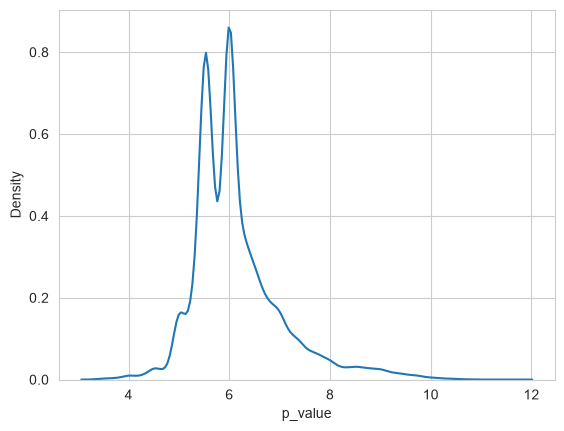

In [628]:
g = sns.kdeplot(nm, x="p_value")

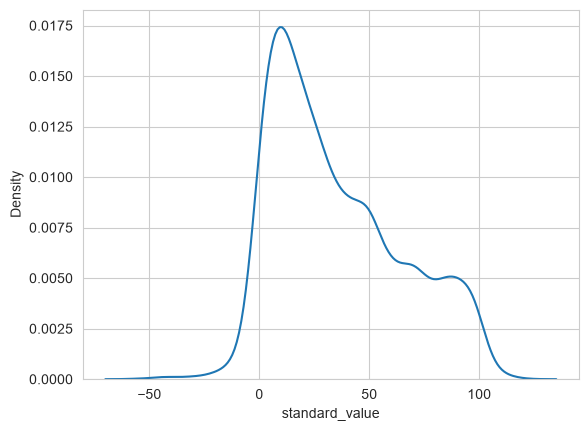

In [629]:
g = sns.kdeplot(pc, x="standard_value")

In [630]:
df = pl.concat([nm, pc], how='diagonal_relaxed')

In [631]:
df['standard_relation'].value_counts()

standard_relation,count
str,u32
""">""",12271
"""<=""",7
"""<""",739
"""=""",24007
"""~""",3
""">=""",31


In [632]:
df = df.with_columns(
    pl.when(
        pl.col("standard_relation").is_in(["<=", "<"])
    ).then(pl.lit("Left Censored"))
    .when(
        pl.col("standard_relation").is_in([">=", ">"])
    ).then(pl.lit("Right Censored"))
    .when(
        pl.col("standard_relation") == "~"
    ).then(pl.lit("Approximate"))
    .when(
        pl.col("standard_relation") == "="
    ).then(pl.lit("Equal"))
    .otherwise(pl.lit("Missing"))
    .alias("Relation Flag")
)

In [634]:
write_pl(df, "../data/ChEMBL/intermediate/15_unit_conversion.xlsx")

## Quality Comments

In [635]:
df = read_pl("../data/ChEMBL/intermediate/15_unit_conversion.xlsx")

Could not determine dtype for column 32, falling back to string
Could not determine dtype for column 34, falling back to string


In [636]:
df = df.with_columns(
    pl.col("Mechanism").str.split("_").list.first().alias("PMechanism"),
    pl.col("Readout").str.split("_").list.first().alias("PReadout"),
)

In [637]:
df = df.with_columns(
    pl.when(
        pl.col("data_validity_comment") == "Outside typical range"
    ).then(pl.lit("Range"))
    .when(
        pl.col("data_validity_comment") == "Potential transcription error"
    ).then(pl.lit("Transcription"))
    .otherwise(pl.lit("No Issues"))
    .alias("Validity Flag")
)

In [640]:
# Split data by endpoint type
ic50 = df.filter(pl.col("standard_type") == "IC50")
k = df.filter(pl.col("standard_type").is_in(["Kd", "Ki"]))
inh = df.filter(pl.col("standard_type") == "Inhibition")

/var/folders/x7/nt253mgd7cxcv4h4jqqbh32c0000gn/T/ipykernel_54336/996109560.py:20: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=sub_df, x="p_value", hue="Validity Flag", ax=ax, legend=False, common_norm=False, palette=pal_map)


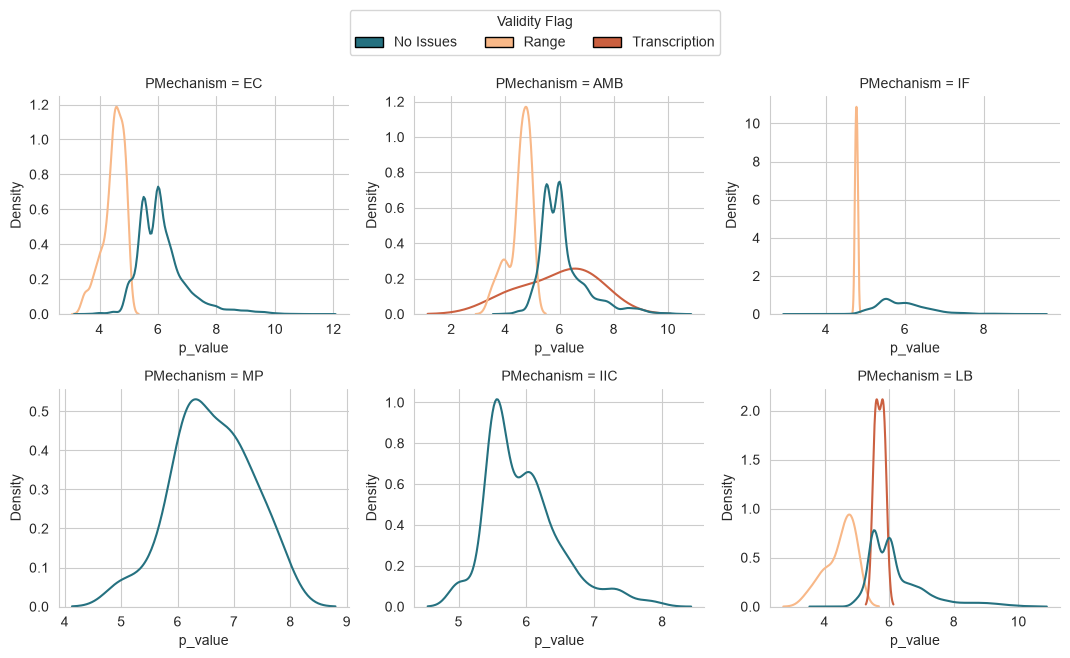

In [641]:
pal = six_point_palette()
pal_map = {
    "No Issues": pal[0],
    "Range": pal[3],
    "Transcription": pal[-1],
}

g = sns.FacetGrid(
    data=ic50,
    col="PMechanism",
    sharex=False,
    sharey=False,
    col_wrap=3,
    aspect=1.2
)

for ax in g.axes.flatten():
    pmech = ax.title.get_text().split(" = ")[-1]
    sub_df = ic50.filter(pl.col("PMechanism") == pmech)
    sns.kdeplot(data=sub_df, x="p_value", hue="Validity Flag", ax=ax, legend=False, common_norm=False, palette=pal_map)

labels = sorted(ic50["Validity Flag"].unique().to_list())
handles = [Patch(label=label, edgecolor="black", facecolor=pal_map.get(label)) for label in labels]
plt.tight_layout()
plt.legend(handles=handles, labels=labels, loc="upper center", ncol=3, title="Validity Flag", bbox_to_anchor=(0.5, 1.10), bbox_transform=g.figure.transFigure)

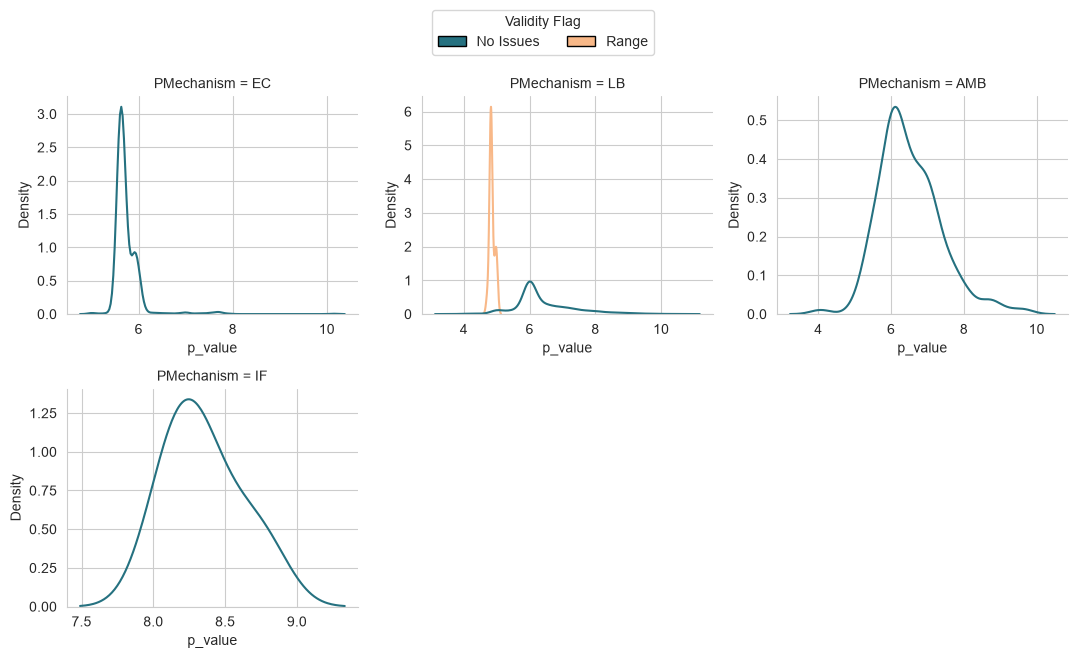

In [642]:
pal = six_point_palette()
pal_map = {
    "No Issues": pal[0],
    "Range": pal[3],
    "Transcription": pal[-1],
}

g = sns.FacetGrid(
    data=k,
    col="PMechanism",
    sharex=False,
    sharey=False,
    col_wrap=3,
    aspect=1.2
)

for ax in g.axes.flatten():
    pmech = ax.title.get_text().split(" = ")[-1]
    sub_df = k.filter(pl.col("PMechanism") == pmech)
    sns.kdeplot(data=sub_df, x="p_value", hue="Validity Flag", ax=ax, legend=False, common_norm=False, palette=pal_map)

labels = sorted(k["Validity Flag"].unique().to_list())
handles = [Patch(label=label, edgecolor="black", facecolor=pal_map.get(label)) for label in labels]
plt.tight_layout()
plt.legend(handles=handles, labels=labels, loc="upper center", ncol=3, title="Validity Flag", bbox_to_anchor=(0.5, 1.10), bbox_transform=g.figure.transFigure)

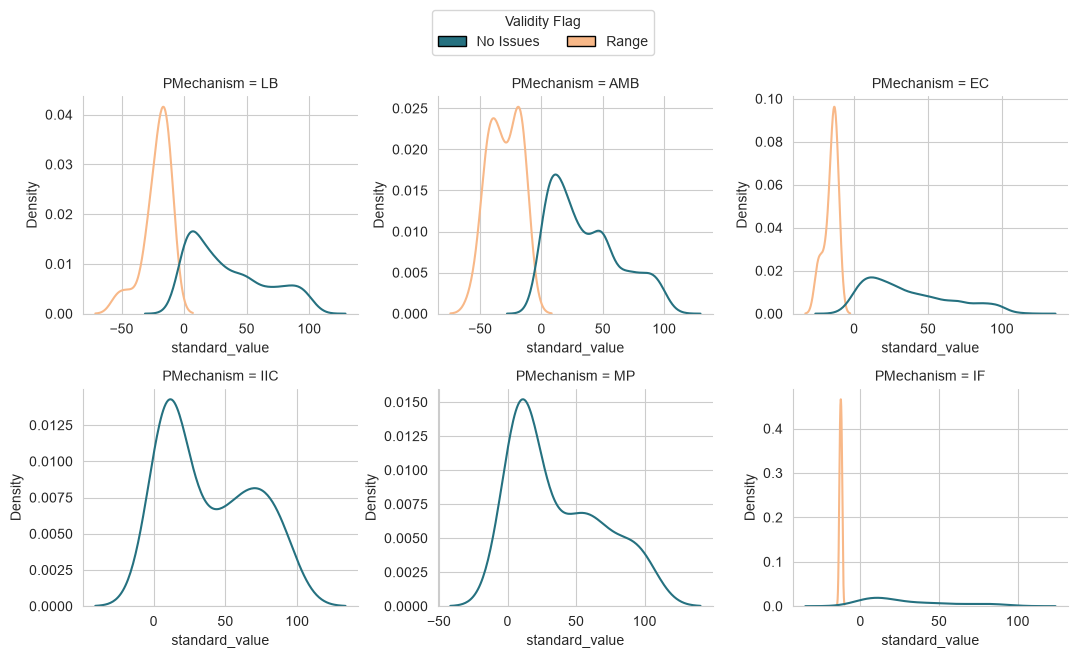

In [643]:
pal = six_point_palette()
pal_map = {
    "No Issues": pal[0],
    "Range": pal[3],
    "Transcription": pal[-1],
}

g = sns.FacetGrid(
    data=inh,
    col="PMechanism",
    sharex=False,
    sharey=False,
    col_wrap=3,
    aspect=1.2
)

for ax in g.axes.flatten():
    pmech = ax.title.get_text().split(" = ")[-1]
    sub_df = inh.filter(pl.col("PMechanism") == pmech)
    sns.kdeplot(data=sub_df, x="standard_value", hue="Validity Flag", ax=ax, legend=False, common_norm=False, palette=pal_map)

labels = sorted(inh["Validity Flag"].unique().to_list())
handles = [Patch(label=label, edgecolor="black", facecolor=pal_map.get(label)) for label in labels]
plt.tight_layout()
plt.legend(handles=handles, labels=labels, loc="upper center", ncol=3, title="Validity Flag", bbox_to_anchor=(0.5, 1.10), bbox_transform=g.figure.transFigure)

Could not determine dtype for column 32, falling back to string
Could not determine dtype for column 34, falling back to string


In [ ]:
"""
We have tested some quantile-based approaches, also within specific underlying mechanisms, but these still cause some of the values in the curator-flagged ranges to be meh. Not knowing anything specific about the data, we censor measurements that are below 4.0 or above 11.0 pIC50/pKa/pKd. For Inhibition data, we censor values above 100% to 100%, values in the [-20, 0]% range to 0%, and anything below 20% is flagged to be dropped as these could potentially correspond to activators and not inhibitors.
"""

In [644]:
ick = pl.concat([ic50, k])

In [645]:
ick = ick.with_columns(
    pl.when(
        pl.col("p_value") < 4.0
    ).then(
        pl.struct(
            standard_relation=pl.lit(">"),
            standard_value=pl.lit(10**(-4.0) * 1e9),
            standard_units=pl.lit("nM"),
            p_value=pl.lit(4.0)
        )
    )
    .when(
        pl.col("p_value") > 11.0
    ).then(
        pl.struct(
            standard_relation=pl.lit("<"),
            standard_value=pl.lit(10**(-11.0) * 1e9),
            standard_units=pl.lit("nM"),
            p_value=pl.lit(11.0)
        )
    )
    .otherwise(
        pl.struct(
            standard_relation=pl.col("standard_relation"),
            standard_value=pl.col("standard_value"),
            standard_units=pl.col("standard_units"),
            p_value=pl.col("p_value")
        )
    )
    .alias("_tmp")
).drop(["standard_relation", "standard_value", "standard_units", "p_value"]).unnest("_tmp")

In [646]:
inh = inh.with_columns(
    pl.when(
        pl.col("standard_value") > 100.0
    ).then(
        pl.struct(
            standard_relation=pl.lit(">"),
            standard_value=pl.lit(100.0),
            standard_units=pl.lit("%"),
            p_value=pl.lit(None)
        )
    )
    .when(
        pl.col("standard_value").is_between(-20.0, 0.0)
    ).then(
        pl.struct(
            standard_relation=pl.lit("<"),
            standard_value=pl.lit(0),
            standard_units=pl.lit("%"),
            p_value=pl.lit(None)
        )
    )
    .when(
        pl.col("standard_value") < -20.0
    ).then(
        pl.struct(
            standard_relation=pl.lit("<"),
            standard_value=pl.lit(-20),
            standard_units=pl.lit("%"),
            p_value=pl.lit(None)
        )
    )
    .otherwise(
        pl.struct(
            standard_relation=pl.col("standard_relation"),
            standard_value=pl.col("standard_value"),
            standard_units=pl.col("standard_units"),
            p_value=pl.lit(None)
        )
    )
    .alias("_tmp")
).drop(["standard_relation", "standard_value", "standard_units", "p_value"]).unnest("_tmp")

In [647]:
print(f"Initial inhibition measurements: {(init_len := len(inh))}")
inh = inh.filter(
    pl.col("standard_value") >= 0.0
)
print(f"Dropped suspected outliers: {init_len - len(inh)}")

Initial inhibition measurements: 7120
Dropped suspected outliers: 30


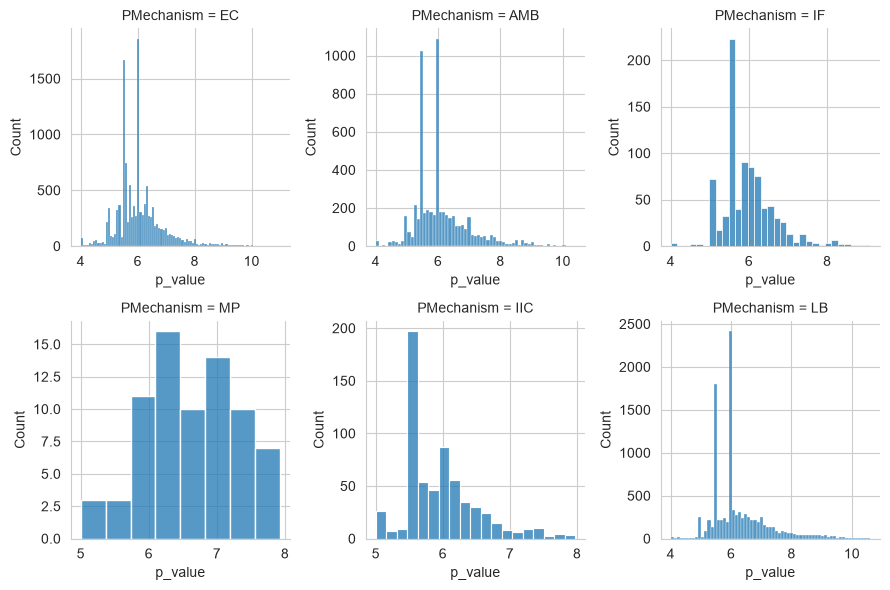

In [648]:
g = sns.FacetGrid(
    data=ick,
    col="PMechanism",
    sharex=False,
    sharey=False,
    col_wrap=3
)

for ax in g.axes.flatten():
    pmech = ax.title.get_text().split(" = ")[-1]
    sub_df = ick.filter(pl.col("PMechanism") == pmech)
    sns.histplot(sub_df, x="p_value", ax=ax)

plt.tight_layout()

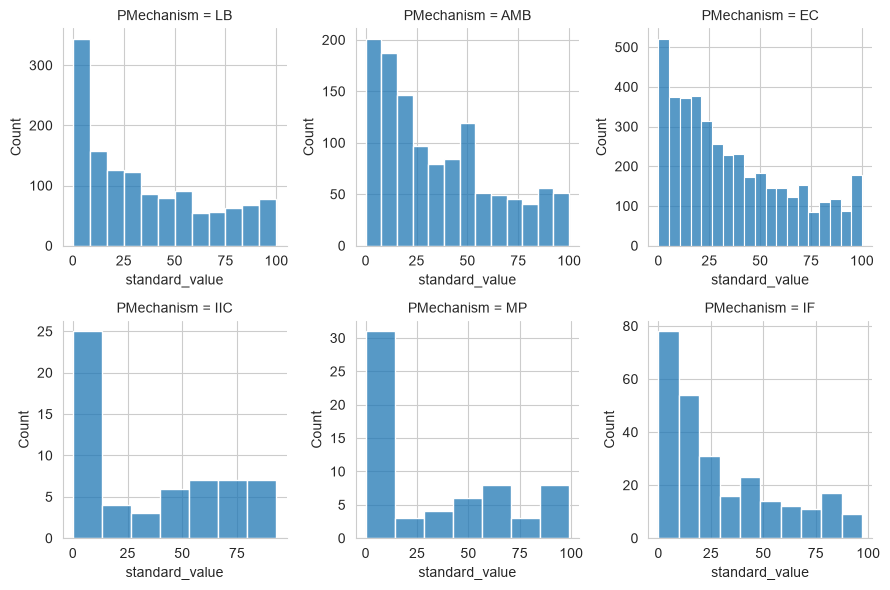

In [649]:
g = sns.FacetGrid(
    data=inh,
    col="PMechanism",
    sharex=False,
    sharey=False,
    col_wrap=3
)

for ax in g.axes.flatten():
    pmech = ax.title.get_text().split(" = ")[-1]
    sub_df = inh.filter(pl.col("PMechanism") == pmech)
    sns.histplot(sub_df, x="standard_value", ax=ax)

plt.tight_layout()

In [650]:
df = pl.concat([ick, inh])

In [651]:
write_pl(df, "../data/ChEMBL/intermediate/16_quality.xlsx")

## Retrieve compounds by molregno

In [109]:
df = read_pl("../data/ChEMBL/intermediate/16_quality.xlsx")
comp_df = read_pl("../data/ChEMBL/maps/compound_structures.tsv")

Could not determine dtype for column 29, falling back to string
Could not determine dtype for column 31, falling back to string


In [110]:
df = df.join(comp_df, on="molregno", how="left")

In [111]:
print(f"Initial size: {(init_len := len(df))}")
df = df.filter(pl.col("canonical_smiles").is_not_null())
print(f"Dropped: {init_len - len(df)}")

Initial size: 37028
Dropped: 97


## Final manipualtions

In [112]:
df = df.with_columns(
    pl.col("gene_name").str.to_uppercase().alias("gene_name")
)
df = df.with_columns(
    pl.when(
        pl.col("gene_name") == "KCNQ1;MINK1" # a slip in gene processing scheme, target was changed, the gene name was not
    ).then(pl.lit("KCNE1;KCNQ1"))
    .otherwise(pl.col("gene_name")).alias("gene_name")
)

In [113]:
df = df.drop([
    "assay_description_1", # duplicate for manual annotation convenience
    "target_name", # not needed anymore
    "BAO Class", # not needed anymore
    "doi", "pubmed_id", # not needed anymore,
    "#Compounds", # not needed; not up to date
    "pchembl_value", # superseded by p_value
    "action_type", # no more entries dropped based on it
    "Validity Flag", # range corrected
])

In [114]:
# Final changes in preparation for the analyses

docs_df = read_pl("../data/ChEMBL/maps/document_year.tsv")
df = df.join(docs_df, on="document_chembl_id", how="left")
df = df.with_columns(
    pl.col("gene_name").str.to_uppercase().alias("Gene Name")
)

gene_map ={
    'CACNA1C;CACNA2D1;CACNB1': 'Cav1.2',
    'CACNA1C;CACNA2D1;CACNB2': 'Cav1.2',
    'SCN5A': 'Nav1.5',
    'CACNA1C;CACNB2': 'Cav1.2',
    'KCNH2': 'hERG',
    'KCND3': 'Kv4.3',
    'KCNQ1': 'Kv7.1',
    'KCND3;KCNIP2': 'Kv4.3',
    'CACNA1C': 'Cav1.2',
    'SCN1B;SCN2B;SCN5A': 'Nav1.5',
    'SCN1B;SCN5A': 'Nav1.5',
    'KCNJ2': 'Kir2.1',
    'KCNE1;KCNQ1': 'Kv7.1',
    'CACNA1C;CACNA2D1;CACNB3': 'Cav1.2'}

df = df.with_columns(
    pl.col("Gene Name").map_elements(
        lambda gene: gene_map.get(gene),
        return_dtype=pl.String
    ).alias("Channel")
)

df = df.filter(
    pl.col("standard_value").is_not_null()
)

In [115]:
# Drop
df = df.drop(["assay_type", "Metadata", "activity_comment", "data_validity_comment", "potential_duplicate", "Record metadata", "REConc", "Mechanism", "Readout","gene_name", "Confidence Flag", "Gene Tier", "Organism Flag", "Cell Flag", "Label Flag", "Relation Flag"])

In [116]:
# Rename
df = df.rename({
    "confidence_score": "assay_confidence_score",
    "Gene organism": "gene_organism",
    "uniprot_accession": "target_uniprot_id",
    "Expression system": "expression_system",
    "Expression organism": "expression_system_organism",
    "Organism Class": "gene_organism_class",
    "Channel Type": "target_channel_class",
    "Cell Class": "expression_system_class",
    "PMechanism": "assay_mechanism",
    "PReadout": "assay_readout",
    "p_value": "pX",
    "Gene Name": "gene_name",
    "Channel": "target_channel_name",
})

In [117]:
df.columns

['assay_chembl_id',
 'assay_description',
 'assay_confidence_score',
 'target_chembl_id',
 'target_type',
 'gene_organism',
 'target_uniprot_id',
 'document_chembl_id',
 'expression_system',
 'expression_system_organism',
 'gene_organism_class',
 'target_channel_class',
 'expression_system_class',
 'molregno',
 'standard_type',
 'assay_mechanism',
 'assay_readout',
 'standard_relation',
 'standard_value',
 'standard_units',
 'pX',
 'standard_inchi_key',
 'canonical_smiles',
 'standard_inchi',
 'year',
 'gene_name',
 'target_channel_name']

In [118]:
# Sort
df = df.select([
    "assay_chembl_id", "assay_description", "assay_confidence_score", "assay_mechanism", "assay_readout",
    "target_chembl_id", "target_uniprot_id", "target_type", "target_channel_name", "target_channel_class",
    "document_chembl_id", "year",
    "gene_name", "gene_organism", "gene_organism_class",
    "expression_system", "expression_system_class", "expression_system_organism",
    "molregno", "canonical_smiles", "standard_inchi", "standard_inchi_key",
    "standard_type", "standard_relation", "standard_value", "standard_units", "pX",
])

In [119]:
write_pl(df, "../data/ChEMBL/processed/chembl_measurements.xlsx")

In [ ]:
"""
At this step, the dataset is sufficiently prepared to be used for the analysis.
Naturally, as we note in the review, the usable count will drop following the standardization of chemical structures,
deduplication of censored value and endpoint. As these are lab-dependent, we use this dataset to show
the upper bound of measurements.
"""